In [21]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import nifty8 as ift
import numpy as np
import resolve as rve

from copy import deepcopy
from scipy.ndimage import convolve1d

from aim_resolve import Observation, SignalSpace, plot_arrays, check_type

jax.config.update("jax_enable_x64", True)

In [33]:
def build_exact_responses(obs, space):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l


def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val


def compute_noise_kernel(RNR, relativ_min_val=0.):
    '''Build the inverse noise kernel for the given RNR operator.'''
    dom = RNR.domain
    shp = dom.shape
    FFT = ift.FFTOperator(RNR.domain)

    delta = np.zeros(shp)
    delta[shp[0]//2, shp[1]//2] = 1 / dom.scalar_weight()
    delta = ift.makeField(dom, delta)
    kernel = RNR(delta).val
    kernel = np.roll(kernel, -shp[0]//2, axis=0)
    kernel = np.roll(kernel, -shp[1]//2, axis=1)
    kernel = ift.makeField(RNR.target, kernel)
    FFT = ift.FFTOperator(RNR.domain)
    max_val = np.max(FFT(kernel).abs().val)
    min_val = relativ_min_val * max_val
    min_val = ift.full(FFT.target, min_val)
    min_val_adder = ift.Adder(min_val)

    pos_eig_val = ift.Operator.identity_operator(FFT.target).exp()
    pos_eig_val = min_val_adder @ pos_eig_val
    rls1 = ift.Realizer(pos_eig_val.target)
    rls2 = ift.Realizer(FFT.domain)

    kernel_pos = rls2 @ FFT.inverse @ rls1.adjoint @ pos_eig_val

    cov = ift.ScalingOperator(kernel_pos.target, 1e-2*max_val)
    lh = ift.GaussianEnergy(data=kernel, inverse_covariance=cov.inverse) @ kernel_pos
    init_pos = (FFT(kernel) - min_val).abs().log()
    energy = ift.EnergyAdapter(position=init_pos, op=lh, want_metric=True)

    ic_newton = ift.DeltaEnergyController(name='Newton', iteration_limit=80, tol_rel_deltaE=0)
    minimizer = ift.NewtonCG(ic_newton)
    res = minimizer(energy)[0].position

    return pos_eig_val(res).val


def fft_fun(space):
    check_type(space, SignalSpace)
    dvol = space.dis.prod()
    print('dvol:', dvol)
    return lambda x: dvol * jnp.fft.fftn(x)


def ifft_fun(space):
    check_type(space, SignalSpace)
    dvol = 1. / (space.shp * space.dis).prod()
    print('dvol:', dvol)
    npix = space.size
    print('npix:', npix)
    return lambda x: dvol * npix * jnp.fft.ifftn(x)


def shift_kernel(kernel):
    shifted_kernel = np.roll(kernel, -kernel.shape[0]//2, axis=0)
    shifted_kernel = np.roll(shifted_kernel, -kernel.shape[1]//2, axis=1)
    return shifted_kernel


def downsample(array, factor):
    if factor == 1:
        return array
    if factor in (2,4,8):
        return array.reshape(-1, factor).mean(axis=1)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')
    
def upsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2, 4, 8):
        return array.repeat(factor)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')


def plot_1d(*arrays, figsize=(5,2), norm='linear', title='',
            offset=1, vmin=None, vmax=None, cmap='Paired'):
    plt.figure(figsize=figsize)
    colors = plt.colormaps.get_cmap(cmap)

    if norm == 'log':
        min_a = min([a[a > 0].min() for a in arrays if np.any(a > 0)])
    for i, a in enumerate(arrays):
        if a.size != arrays[0].size:
            raise ValueError("All arrays must have the same size")
        a = np.array(a)
        if norm == 'log':
            a[a <= 0] = min_a
        if offset:
            a = a[offset:-offset]
        plt.plot(np.arange(a.size), a, color=colors(i))

    plt.yscale(norm)
    if vmin is not None or vmax is not None:
        plt.ylim(vmin, vmax)
    plt.title(title)
    plt.show()

In [13]:
obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()
print(obs)

Observation:
  Source name:		None
  Visibilities shape:	(1, 3668965, 7)
  # visibilities:	25682755
  Frequency range:	986.720 -- 1137.188 MHz
  Polarizations:	I
  Shortest baseline:	0.0 m -> inf deg
  Longest baseline:	7697.6 m -> 7.064 arcsec
  Flagged:		38.1%


/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/resolve/data/observation.py:754: RuntimeWarning: divide by zero encountered in scalar divide
  short1 = 1/(short0*self.freq.min()/SPEEDOFLIGHT)


SignalSpace(shape=(512, 512), distances=(3.408846195301425e-05, 3.408846195301425e-05), center=(0.0, 0.0), rotation=0.0)


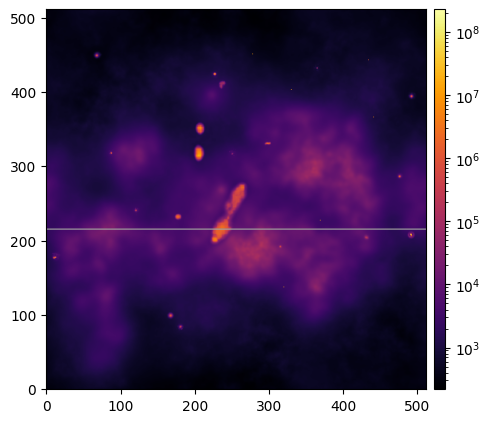

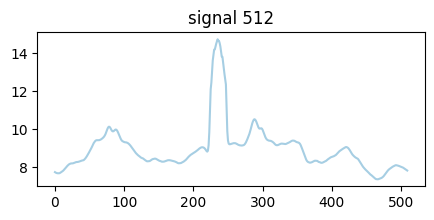

In [17]:
fname = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_rec.pkl'
sky_2d_512 = np.load(fname, allow_pickle=True)[0]
space_2d_512 = SignalSpace.build(shape=sky_2d_512.shape, fov=('1deg', '1deg'))
print(space_2d_512)

slc = 215 #207
signal_slc = sky_2d_512.copy()
signal_slc[:, slc] = np.nan
plot_arrays(signal_slc, norm='log', dpi=100)

sky_1d_512 = sky_2d_512[:, slc]

sky_1d_512 = np.log(sky_1d_512)
plot_1d(sky_1d_512, norm='linear', title='signal 512')

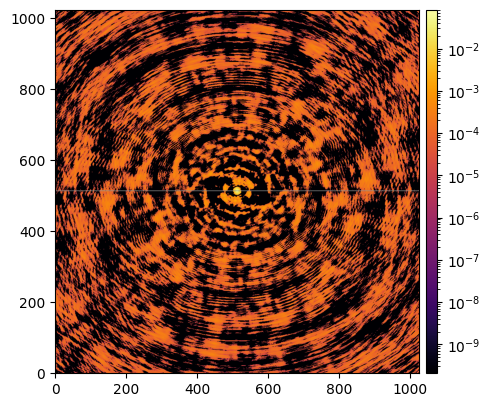

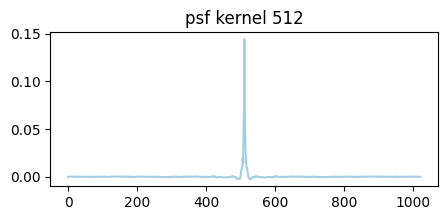

In [19]:
R, R_l, RNR, RNR_l = build_exact_responses(obs, space_2d_512)

psf_kernel_2d_512 = compute_psf_kernel(RNR_l)

slc = 512 #207
psf_kernel_slc = psf_kernel_2d_512.copy()
psf_kernel_slc[:, slc] = np.nan
plot_arrays(psf_kernel_slc, norm='log', dpi=100)

psf_kernel_1d_512 = psf_kernel_2d_512[:, slc]
plot_1d(psf_kernel_1d_512, norm='linear', title='psf kernel 512')

In [36]:
fourier_noise_kernel_2d_512 = compute_noise_kernel(RNR, 1e-3)

Newton: Iteration #0 energy=2.736484E+06 reldiff=1.000000E+00 clvl=0
Iteration limit reached. Assuming convergence
Newton: Iteration #1 energy=2.166923E+06 reldiff=2.081358E-01 clvl=0
Newton: Iteration #2 energy=2.164253E+06 reldiff=1.232529E-03 clvl=0
Newton: Iteration #3 energy=2.092259E+06 reldiff=3.326499E-02 clvl=0
Newton: Iteration #4 energy=2.092135E+06 reldiff=5.906247E-05 clvl=0
 Iteration limit reached. Assuming convergence
Newton: Iteration #5 energy=2.010290E+06 reldiff=3.912025E-02 clvl=0
Newton: Iteration #6 energy=2.010170E+06 reldiff=5.962656E-05 clvl=0
 Iteration limit reached. Assuming convergence
Newton: Iteration #7 energy=1.991187E+06 reldiff=9.443630E-03 clvl=0
Newton: Iteration #8 energy=1.991084E+06 reldiff=5.178276E-05 clvl=0
 Iteration limit reached. Assuming convergence
Newton: Iteration #9 energy=1.980211E+06 reldiff=5.460730E-03 clvl=0
Newton: Iteration #10 energy=1.980198E+06 reldiff=6.642336E-06 clvl=0
 Iteration limit reached. Assuming convergence
Newton

dvol: 3282.806350011744
npix: 262144


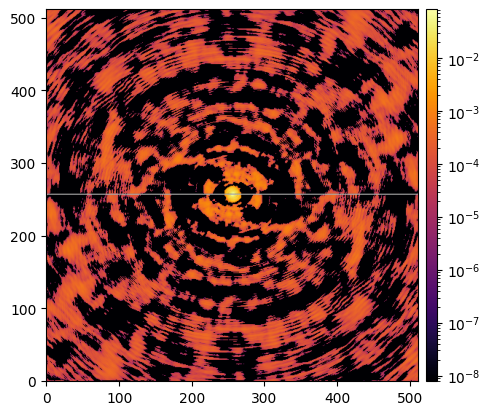

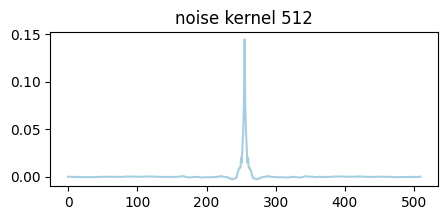

In [37]:
noise_kernel_2d_512 = ifft_fun(space_2d_512)(fourier_noise_kernel_2d_512).real
noise_kernel_2d_512 = shift_kernel(noise_kernel_2d_512)

slc = 256
noise_kernel_slc = noise_kernel_2d_512.copy()
noise_kernel_slc[:, slc] = np.nan
plot_arrays(noise_kernel_slc, norm='log', dpi=100)

noise_kernel_1d_512 = noise_kernel_2d_512[:, slc]
plot_1d(noise_kernel_1d_512, norm='linear', title='noise kernel 512')

In [38]:
signal_bg = sky_2d_512[140, :]

peak = sky_2d_512[:, 215]
peak = np.log(peak) - 9.5
peak = np.where(peak > 0, peak, 0)
# plot_1d(peak)

slc_t0 = slice(200, 264)
signal_t0 = np.zeros_like(peak)
signal_t0[slc_t0] = peak[200:264]
signal_t0 = np.exp(signal_t0 * 3)

slc_t1 = slice(270, 334)
signal_t1 = np.zeros_like(peak)
signal_t1[slc_t1] = peak[260:324]
signal_t1 = np.exp(signal_t1 * 15)

idx_p0 = 400
ps_ker = 15
signal_p0 = np.zeros_like(peak)
signal_p0[idx_p0] = np.exp(15)

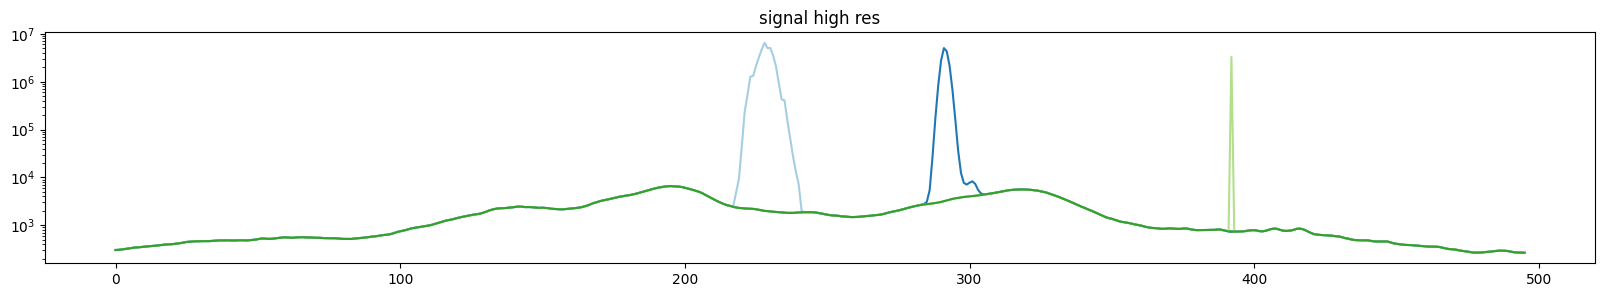

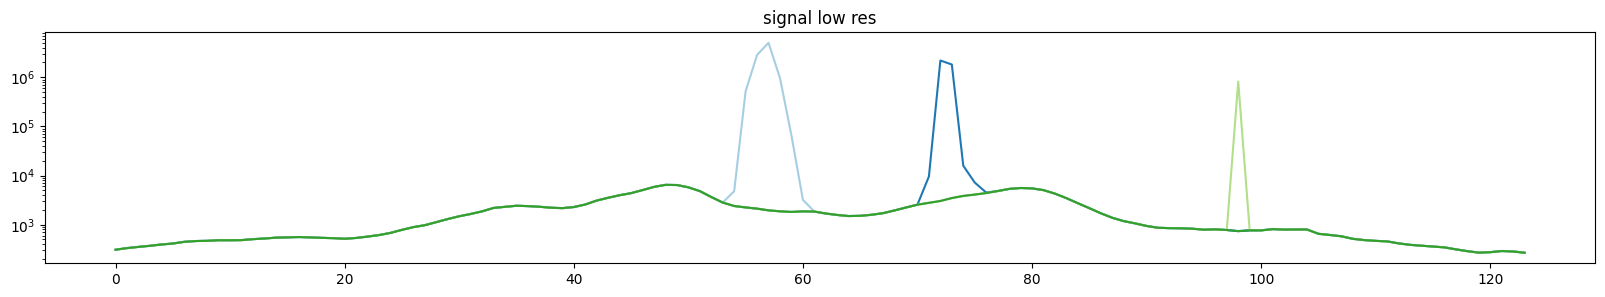

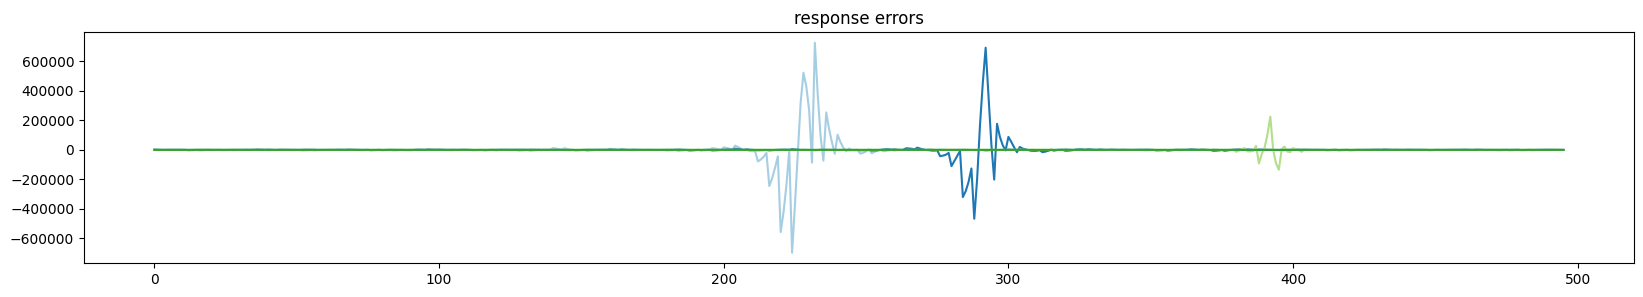

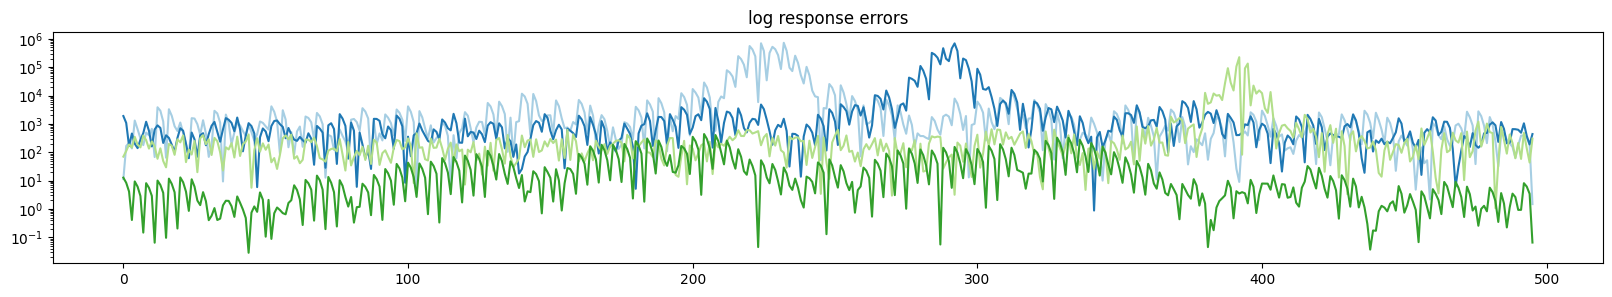

In [43]:
zoom = 4

signal_dict = {
    'sum': {'val': signal_bg + signal_t0 + signal_t1 + signal_p0, 'low': downsample(signal_bg + signal_t0 + signal_t1 + signal_p0, zoom)},
    't0': {'val': signal_t0, 'low': downsample(signal_t0, zoom), 'slc': slc_t0, 'slc_low': slice(slc_t0.start//zoom, slc_t0.stop//zoom)},
    't1': {'val': signal_t1, 'low': downsample(signal_t1, zoom), 'slc': slc_t1, 'slc_low': slice(slc_t1.start//zoom, slc_t1.stop//zoom)},
    'ps': {'val': signal_p0, 'low': downsample(signal_p0, zoom), 'idx': idx_p0, 'ker_pix': 32},
    'bg': {'val': signal_bg, 'low': downsample(signal_bg, zoom)},
    'fac': zoom,
    'shp': signal_bg.size,
}
kernel = psf_kernel_1d_512.copy()

plot_1d(*[signal_dict['bg']['val'] + sig['val'] for k,sig in signal_dict.items() if k in ['t0','t1','ps']], signal_dict['bg']['val'], norm='log', offset=8, figsize=(20,3), title='signal high res')
plot_1d(*[signal_dict['bg']['low'] + sig['low'] for k,sig in signal_dict.items() if k in ['t0','t1','ps']], signal_dict['bg']['low'], norm='log', offset=8//zoom, figsize=(20,3), title='signal low res')

rsp_err = []
low_res_err = np.zeros(signal_dict['shp'])
ker_low = downsample(kernel, zoom)
for k,sig in signal_dict.items():
    if isinstance(sig, dict) and k != 'sum':
        rsp_low = convolve1d(sig['low'], ker_low, mode='constant') * zoom
        rsp_low = upsample(rsp_low, zoom)
        rsp_val = convolve1d(sig['val'], kernel, mode='constant')
        rsp_err += [rsp_val - rsp_low, ]

        if 'bg' in k:
            low_res_err += rsp_val - rsp_low
        if 't' in k:
            sig_box = np.ones(signal_dict['shp'])
            sig_box[sig['slc']] = 0
            low_res_err += (rsp_val - rsp_low) * sig_box
        if 'ps' in k:
            sig_box = np.ones(signal_dict['shp'])
            sig_box[sig['idx']-sig['ker_pix']//2:sig['idx']+sig['ker_pix']//2] = 0
            low_res_err += (rsp_val - rsp_low) * sig_box


plot_1d(*rsp_err, norm='linear', offset=8, figsize=(20,3), title='response errors')
plot_1d(*[np.abs(err) for err in rsp_err], norm='log', offset=8, figsize=(20,3), title='log response errors')


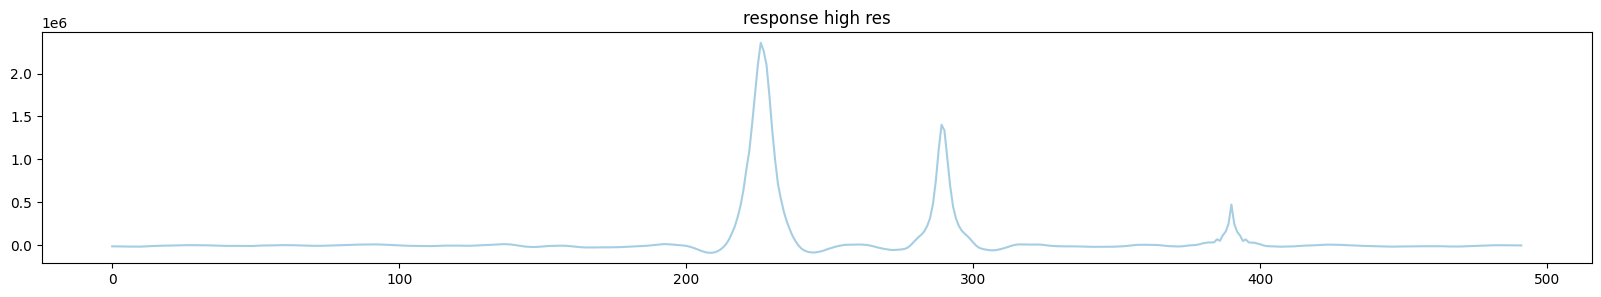

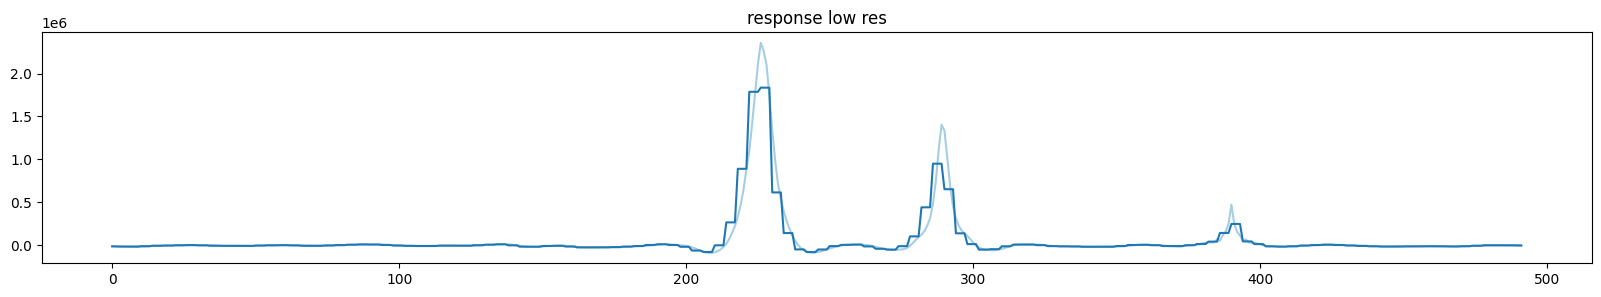

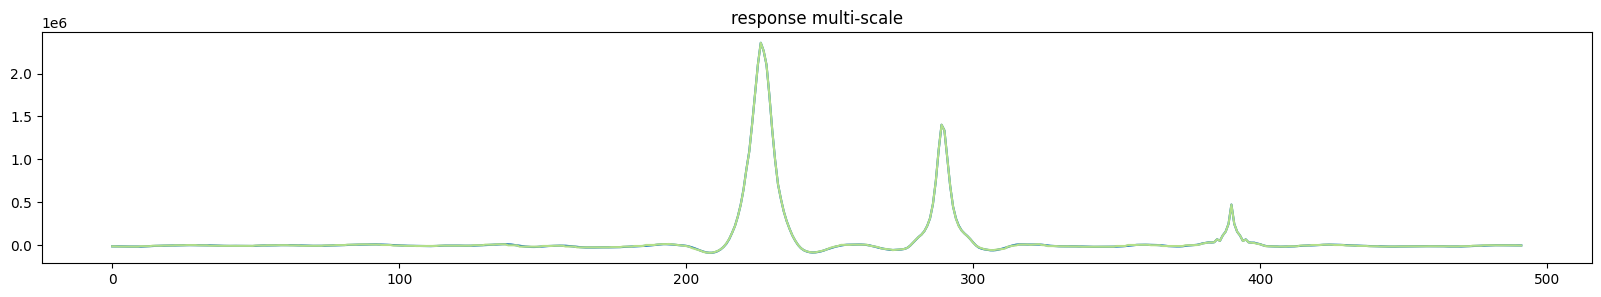

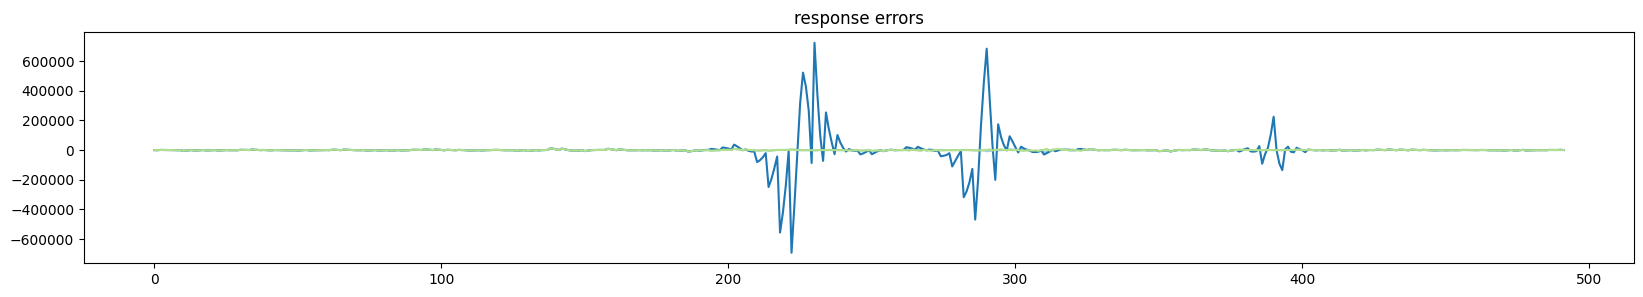

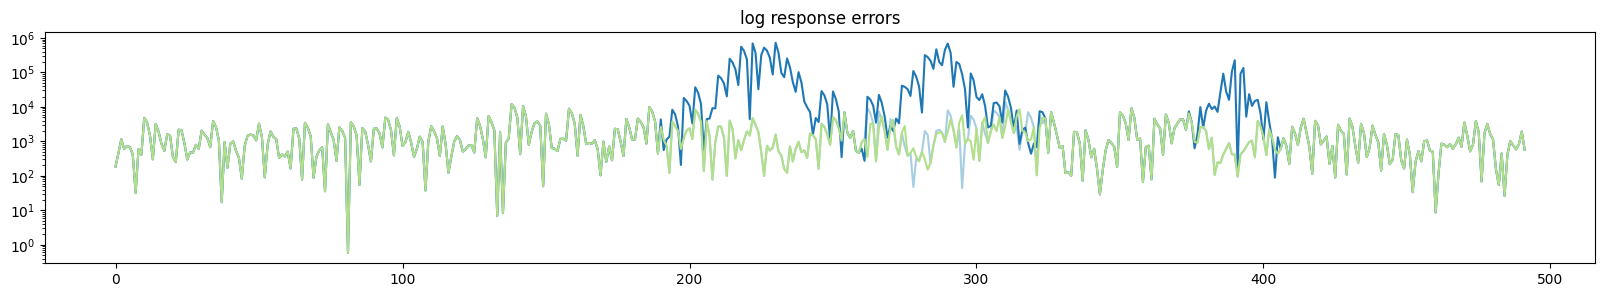

In [41]:
def multi_scale_kernel(signal_dict, kernel):
    signal_dict = deepcopy(signal_dict)
    fac = signal_dict['fac']

    kernel_low = downsample(kernel, fac)
    response_low = convolve1d(signal_dict['sum']['low'], kernel_low, mode='constant') * fac
    response_val = upsample(response_low, fac)

    for key, sig in filter(lambda x: 't' in x[0], signal_dict.items()):
        sig_val = sig['val'][sig['slc']]
        ker_val = kernel[kernel.size // 2 - sig_val.size : kernel.size // 2 + sig_val.size]
        rsp_val = convolve1d(sig_val, ker_val, mode='constant')

        sig_low = sig['low'][sig['slc_low']]
        ker_low = downsample(ker_val, fac)
        rsp_low = convolve1d(sig_low, ker_low, mode='constant') * fac

        rsp_slc = response_low[sig['slc_low']]
        rsp_sub = rsp_slc - rsp_low
        rsp_add = upsample(rsp_sub, fac) + rsp_val
        response_val[sig['slc']] = rsp_add

    for key, sig in filter(lambda x: 'ps' in x[0], signal_dict.items()):
        slc = slice(sig['idx'] - sig['ker_pix']//2, sig['idx'] + sig['ker_pix']//2)
        slc_low = slice(slc.start//fac, slc.stop//fac)

        ker_val = kernel[kernel.size//2 - sig['ker_pix']//2 : kernel.size//2 + sig['ker_pix']//2]
        rsp_val = ker_val * sig['val'][sig['idx']]

        ker_low = downsample(ker_val, fac)
        rsp_low = ker_low * sig['low'][sig['idx']//fac] * fac

        rsp_slc = response_low[slc_low]
        rsp_sub = rsp_slc - rsp_low
        rsp_add = upsample(rsp_sub, fac) + rsp_val
        response_val[slc] = rsp_add

    return response_val


response_high = convolve1d(signal_dict['sum']['val'], kernel, mode='constant')
response_low = convolve1d(signal_dict['sum']['low'], downsample(kernel, signal_dict['fac']), mode='constant') * signal_dict['fac']
response_low = upsample(response_low, signal_dict['fac'])


response_ms = multi_scale_kernel(signal_dict, kernel)

plot_1d(response_high, offset=10, figsize=(20,3), title='response high res')
plot_1d(response_high, response_low, offset=10, figsize=(20,3), title='response low res')
plot_1d(response_high, response_high, response_ms, offset=10, figsize=(20,3), title='response multi-scale')

response_errors = [low_res_err, response_high - response_low, response_high - response_ms]

plot_1d(*response_errors, offset=10, figsize=(20,3), title='response errors')
plot_1d(*[np.abs(err) for err in response_errors], norm='log', offset=10, figsize=(20,3), title='log response errors')